<a href="https://colab.research.google.com/github/mindioanni/LandLevelTools/blob/main/Copy_of_Seismicity_V1_05022025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build the environment

In [ ]:
!pip install geopandas contextily
!pip install cartopy

import os
from IPython import get_ipython
from IPython.core.magic import register_cell_magic
from IPython.display import display, HTML
from IPython.utils.capture import capture_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Import the matplotlib.dates module and alias it as mdates
import matplotlib.animation as animation
from scipy.stats import gaussian_kde
import seaborn as sns
import folium
from folium.plugins import HeatMap
from google.colab import files
from scipy.stats import linregress
import requests
import zipfile
import os
from shapely.geometry import Point, LineString, box
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature


Build the logging/report routine

In [ ]:
# Define the path for the HTML output
html_file_path = "/content/report_log.html"  # Αποθηκεύεται στο Google Colab

# Δημιουργία ή καθαρισμός του HTML αρχείου
with open(html_file_path, "w", encoding='utf-8') as file:
    file.write("<html><head><title>Seismic Report</title></head><body>")
    file.write("<h1>Seismic Report</h1><hr>")

@register_cell_magic
def capture_and_save_html(line, cell):
    """Capture cell execution and append outputs and plots to an HTML file."""
    ipython = get_ipython()

    # Run the cell and capture outputs
    with capture_output() as captured:
        ipython.run_cell(cell)

    # Display captured outputs in the notebook
    if captured.stdout:
        print(captured.stdout)
    if captured.stderr:
        print(captured.stderr)

    for output in captured.outputs:
        if 'data' in dir(output) and 'image/png' in output.data:
            display(HTML(f"<img src='data:image/png;base64,{output.data['image/png']}'/>"))
        if 'text' in dir(output):
            print(output.text)

    # Append captured outputs to an HTML file
    html_content = "<div style='margin:10px 0; padding:10px; border:1px solid #ccc;'>"

    if captured.stdout:
        html_content += f"<pre>{captured.stdout}</pre>"
    if captured.stderr:
        html_content += f"<pre style='color: red;'>{captured.stderr}</pre>"

    for output in captured.outputs:
        if 'data' in dir(output) and 'image/png' in output.data:
            img_html = f"<img src='data:image/png;base64,{output.data['image/png']}'/>"
            html_content += f"<div>{img_html}</div>"
        if 'text' in dir(output):
            html_content += f"<pre>{output.text}</pre>"

    html_content += "</div>"

    # Καταγραφή στο αρχείο
    with open(html_file_path, "a", encoding='utf-8') as file:
        file.write(html_content)


Import long term and short term time series

In [ ]:

# ======= Φόρτωση αρχείων =======
print("Ανεβάστε το αρχείο μακροχρόνιων παρατηρήσεων - τελευταία έτη")
uploaded_10yrs = files.upload()
catalogue_10yrs = list(uploaded_10yrs.keys())[0]
print("\nΑνεβάστε το αρχείο βραχυχρόνιων παρατηρήσεων - τελευταίες εβδομάδες")
uploaded_35day = files.upload()
catalogue_35day = list(uploaded_35day.keys())[0]

Ανεβάστε το αρχείο μακροχρόνιων παρατηρήσεων - τελευταία έτη


Saving catalogue long term prior 60years.csv to catalogue long term prior 60years.csv

Ανεβάστε το αρχείο βραχυχρόνιων παρατηρήσεων - τελευταίες εβδομάδες


Saving catalogue short term.csv to catalogue short term.csv


Download coastlines

In [ ]:
%%capture_and_save_html

import os
import requests
import zipfile
import geopandas as gpd

print(f"**INITIALIZING THE REPORT LOGGING**")
print("\n")
print(f"**Εnvironment already built**")
print("\n")
print(f"**Timeseries already uploaded on system**")
print("\n")
print(f"**Download coastlines and data**")
print("\n")

# ✅ Δημιουργία long-term dataframe
df_10yrs = pd.read_csv(catalogue_10yrs, parse_dates=["Origin Time (GMT)"])
df_10yrs = df_10yrs.sort_values(by="Origin Time (GMT)", ascending=True)
df_10yrs["Seismic Energy"] = 10 ** (5.24 + 1.44 * df_10yrs["Magnitude (ML)"])
df_10yrs["Cumulative Energy"] = df_10yrs["Seismic Energy"].cumsum()

# ✅ Εκτύπωση πληροφοριών για το long-term dataframe
print(f"\n**Long-term DataFrame (df_10yrs) created from file: {catalogue_10yrs}**")
print("\nFirst 5 rows:")
print(df_10yrs.head())
print("\nStatistics:")
print(df_10yrs.describe())
print(f"\nNumber of records: {len(df_10yrs)}")


# ✅ Δημιουργία short-term dataframe
df_35day = pd.read_csv(catalogue_35day, parse_dates=["Origin Time (GMT)"])
df_35day = df_35day.sort_values(by="Origin Time (GMT)", ascending=True)
df_35day["Seismic Energy"] = 10 ** (5.24 + 1.44 * df_35day["Magnitude (ML)"])
df_35day["Cumulative Energy"] = df_35day["Seismic Energy"].cumsum()

# ✅ Εκτύπωση πληροφοριών για το short-term dataframe
print(f"\n**Short-term DataFrame (df_35day) created from file: {catalogue_35day}**")
print("\nFirst 5 rows:")
print(df_35day.head())
print("\nStatistics:")
print(df_35day.describe())
print(f"\nNumber of records: {len(df_35day)}")


# ======= ✅ Κατέβασμα και αποσυμπίεση GSHHG ακτογραμμής (Fine resolution) =======

# ✅ Ορισμός εναλλακτικού URL λήψης
gshhg_url = "https://www.soest.hawaii.edu/pwessel/gshhg/gshhg-shp-2.3.7.zip"
gshhg_zip = "/content/gshhg-shapefiles.zip"
gshhg_dir = "/content/gshhg"

# ✅ Διαγραφή προηγούμενων αρχείων αν υπάρχουν
if os.path.exists(gshhg_zip):
    os.remove(gshhg_zip)
    print("📌 Προηγούμενο αρχείο ZIP διαγράφηκε.")

# ✅ Κατέβασμα του GSHHG shapefile
print("📥 Κατεβάζουμε το GSHHG shapefile από εναλλακτική πηγή...")
response = requests.get(gshhg_url, stream=True)

if response.status_code == 200:
    with open(gshhg_zip, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("✅ Η λήψη του αρχείου ολοκληρώθηκε.")
else:
    raise ConnectionError(f"❌ Αποτυχία λήψης. Status Code: {response.status_code}")

# ✅ Έλεγχος εγκυρότητας του ZIP
if zipfile.is_zipfile(gshhg_zip):
    print("✔️ Το αρχείο είναι έγκυρο ZIP.")
else:
    raise ValueError("❌ Το αρχείο δεν είναι έγκυρο ZIP. Δοκίμασε ξανά.")

# ✅ Αποσυμπίεση αρχείου
if not os.path.exists(gshhg_dir):
    os.makedirs(gshhg_dir)

print("📂 Αποσυμπίεση των GSHHG δεδομένων...")
with zipfile.ZipFile(gshhg_zip, "r") as zip_ref:
    zip_ref.extractall(gshhg_dir)
print("✅ Η αποσυμπίεση ολοκληρώθηκε.")

# ✅ Εντοπισμός του shapefile υψηλής ανάλυσης
coastline_shp = None
for root, dirs, files in os.walk(gshhg_dir):
    for file in files:
        if file.endswith("GSHHS_f_L1.shp"):  # Χρήση ακτογραμμής υψηλής ανάλυσης
            coastline_shp = os.path.join(root, file)
            print(f"🌍 Βρέθηκε το shapefile ακτογραμμής: {coastline_shp}")

# ✅ Φόρτωση των δεδομένων ακτογραμμής
if coastline_shp:
    coastline = gpd.read_file(coastline_shp)
    print("✔️ Τα δεδομένα ακτογραμμής φορτώθηκαν επιτυχώς!")
else:
    raise FileNotFoundError("❌ Δεν βρέθηκε το GSHHS_f_L1.shp μετά την αποσυμπίεση.")

# ✅ Προβολή πρώτων γραμμών για επιβεβαίωση
print(coastline.head())

# ======= ✅ Κατέβασμα του αρχείου ρηγμάτων NOA faults (Fine resolution) =======
# Ορισμός του URL και του ονόματος αποθήκευσης
faults_url = "https://noa-beyondapps.maps.arcgis.com/sharing/rest/content/items/018068b94b41401a910237865776f4d7/data"
faults_csv_path = "/content/NOAFaults_v6.0.gmt.csv"

# Λήψη του αρχείου
response = requests.get(faults_url)

# Έλεγχος αν η λήψη ήταν επιτυχής
if response.status_code == 200:
    with open(faults_csv_path, "wb") as f:
        f.write(response.content)
    print(f"✅ Το αρχείο αποθηκεύτηκε στο {faults_csv_path}")
else:
    print(f"❌ Αποτυχία λήψης του αρχείου. Status code: {response.status_code}")



**INITIALIZING THE REPORT LOGGING**


**Εnvironment already built**


**Timeseries already uploaded on system**


**Download coastlines and data**



**Long-term DataFrame (df_10yrs) created from file: catalogue long term prior 60years.csv**

First 5 rows:
       Origin Time (GMT)  Latitude  Longitude  Depth (km)  Magnitude (ML)  \
2735 1966-03-08 20:29:37      36.7      25.70          10             3.7   
2734 1966-08-18 22:09:38      36.4      26.20         100             4.0   
2733 1967-09-16 21:32:24      36.5      26.25          10             3.5   
2732 1967-10-04 20:30:57      36.2      26.30          10             3.8   
2731 1968-01-27 20:52:41      36.3      25.50          10             3.6   

                  Location  Seismic Energy  Cumulative Energy  
2735   39.5 km NE of Thira    3.698282e+10       3.698282e+10  
2734    68.6 km E of Thira    1.000000e+11       1.369828e+11  
2733    73.6 km E of Thira    1.905461e+10       1.560374e+11  
2732  81.3 km ESE of Thi

Εφαρμογή επιθυμητού εύρους τιμών Μ

In [ ]:
%%capture_and_save_html

print("\n")
print(f"**Apply window for data**")

# ======= Ερώτημα προς τον χρήστη =======
while True:
    user_choice = input("Θέλεις να φιλτραριστούν οι σεισμοί σε συγκεκριμένο εύρος τιμών Μ; (Yes/No): ").strip().lower()
    if user_choice in ["yes", "no"]:
        break
    print("Παρακαλώ απάντησε με Yes ή No.")

if user_choice == "yes":
    while True:
        try:
            min_magnitude = float(input("Δώσε ελάχιστο Μ: ").strip())
            max_magnitude = float(input("Δώσε μέγιστο Μ: ").strip())

            if min_magnitude > max_magnitude:
                print("Το ελάχιστο Μ πρέπει να είναι μικρότερο ή ίσο με το μέγιστο Μ. Προσπάθησε ξανά.")
            else:
                break
        except ValueError:
            print("Παρακαλώ εισήγαγε αριθμητικές τιμές για τα μεγέθη Μ.")

    # ======= Φιλτράρισμα των σεισμών =======
    df_35day = df_35day[(df_35day["Magnitude (ML)"] >= min_magnitude) & (df_35day["Magnitude (ML)"] <= max_magnitude)]
    df_10yrs = df_10yrs[(df_10yrs["Magnitude (ML)"] >= min_magnitude) & (df_10yrs["Magnitude (ML)"] <= max_magnitude)]

    print(f"Έγινε φιλτράρισμα των σεισμών στο εύρος {min_magnitude} ≤ M ≤ {max_magnitude}")
else:
    print("Δεν εφαρμόστηκε φιλτράρισμα στα δεδομένα.")


Θέλεις να φιλτραριστούν οι σεισμοί σε συγκεκριμένο εύρος τιμών Μ; (Yes/No): Yes
Δώσε ελάχιστο Μ: 3
Δώσε μέγιστο Μ: 9


**Apply window for data**
Έγινε φιλτράρισμα των σεισμών στο εύρος 3.0 ≤ M ≤ 9.0



Run the code to create the graphs



**Gutenberg-Richter b value analysis - MLE and Least-Squares**






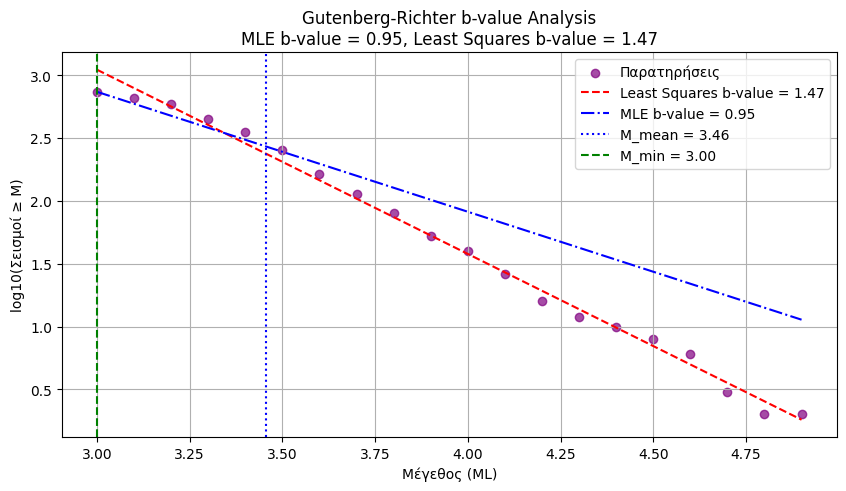

In [ ]:
%%capture_and_save_html

print("\n")
print(f"**Gutenberg-Richter b value analysis - MLE and Least-Squares**")
print("\n")

# Append explanation to the HTML report with MathJax for LaTeX rendering
explanation_html = """
<div style="margin: 20px; padding: 10px; border: 1px solid #ccc; font-family: Arial, sans-serif;">
    <h3>Gutenberg-Richter <i>b-value</i> Analysis</h3>
    <p>The following code calculates the <b>b-value</b> using the <b>Maximum Likelihood Estimation (MLE)</b> method, as proposed by <b>Aki (1965)</b>:</p>
    <div style="background: #f9f9f9; padding: 10px; border: 1px solid #ddd; font-family: 'Courier New', monospace;">
        $$ b_{\\text{MLE}} = \\frac{\\log_{10} e}{M_{\\text{mean}} - M_{\\text{min}}} $$
    </div>
    <p>where:</p>
    <ul>
        <li><b>\( M_{\\text{mean}} \)</b> is the mean magnitude of the earthquakes in the sample,</li>
        <li><b>\( M_{\\text{min}} \)</b> is the minimum magnitude considered (due to completeness of data),</li>
        <li><b>\( \\log_{10} e \\approx 0.4343 \)</b> is the transformation from natural logarithms to base-10 logarithms.</li>
    </ul>
</div>
<script src="https://polyfill.io/v3/polyfill.min.js?features=es6"></script>
<script id="MathJax-script" async src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>
"""

# Save to the HTML report file
with open(html_file_path, "a", encoding='utf-8') as file:
    file.write(explanation_html)

# --- Gutenberg-Richter Ανάλυση (10 χρόνια) ---
magnitudes = df_10yrs["Magnitude (ML)"]

# Επιλογή του κατώτατου μεγέθους M_min (συνήθως το κατώτερο πλήρες μέγεθος των δεδομένων)
M_min = magnitudes.min()

# Υπολογισμός MLE b-value
M_mean = magnitudes.mean()
b_value_mle = np.log10(np.e) / (M_mean - M_min)

# --- Least Squares Fit (για σύγκριση) ---
bins = np.arange(M_min, magnitudes.max() + 0.1, 0.1)
counts, edges = np.histogram(magnitudes, bins=bins)
cumulative_counts = np.cumsum(counts[::-1])[::-1]

# Φιλτράρισμα για αποφυγή log(0)
valid_indices = cumulative_counts > 0
log_counts = np.log10(cumulative_counts[valid_indices])
log_mags = edges[:-1][valid_indices]

# Γραμμική παλινδρόμηση (Least Squares Fit)
slope, intercept, _, _, _ = linregress(log_mags, log_counts)
b_value_ls = -slope

# Υπολογισμός intercept για το MLE b-value
#mle_intercept = log_counts[0] - b_value_mle * log_mags[0]
mle_intercept = log_counts[0] + b_value_mle * log_mags[0]


# --- Σύγκριση των δύο μεθόδων ---
plt.figure(figsize=(10, 5))
plt.scatter(log_mags, log_counts, color='purple', alpha=0.7, label="Παρατηρήσεις")
plt.plot(log_mags, slope * log_mags + intercept, 'r--', label=f"Least Squares b-value = {b_value_ls:.2f}")
plt.plot(log_mags, -b_value_mle * log_mags + mle_intercept, 'b-.', label=f"MLE b-value = {b_value_mle:.2f}")

plt.axvline(M_mean, color='blue', linestyle=':', label=f"M_mean = {M_mean:.2f}")
plt.axvline(M_min, color='green', linestyle='--', label=f"M_min = {M_min:.2f}")

plt.xlabel("Μέγεθος (ML)")
plt.ylabel("log10(Σεισμοί ≥ M)")
plt.title(f"Gutenberg-Richter b-value Analysis\nMLE b-value = {b_value_mle:.2f}, Least Squares b-value = {b_value_ls:.2f}")
plt.legend()
plt.grid()
plt.show()




**Time-series diagrams**




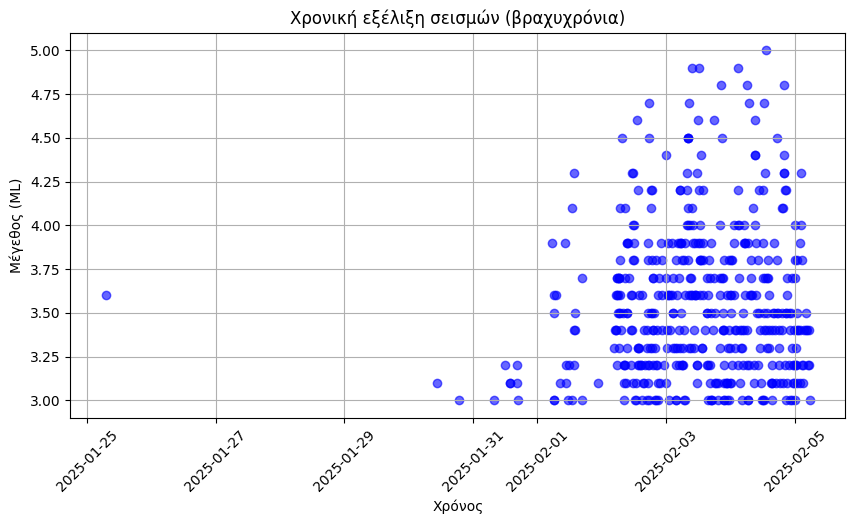


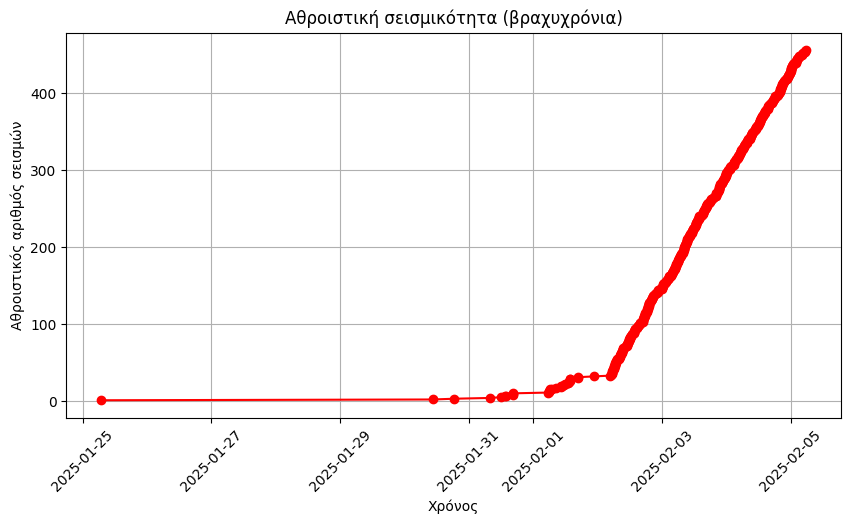


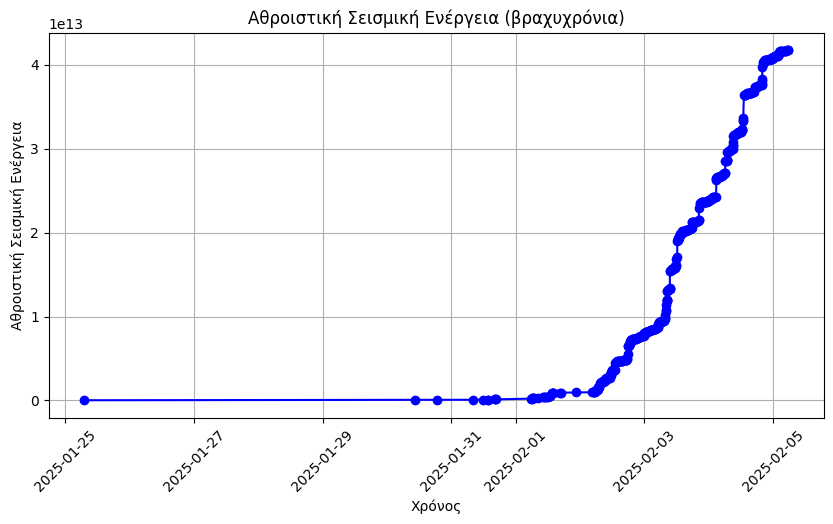


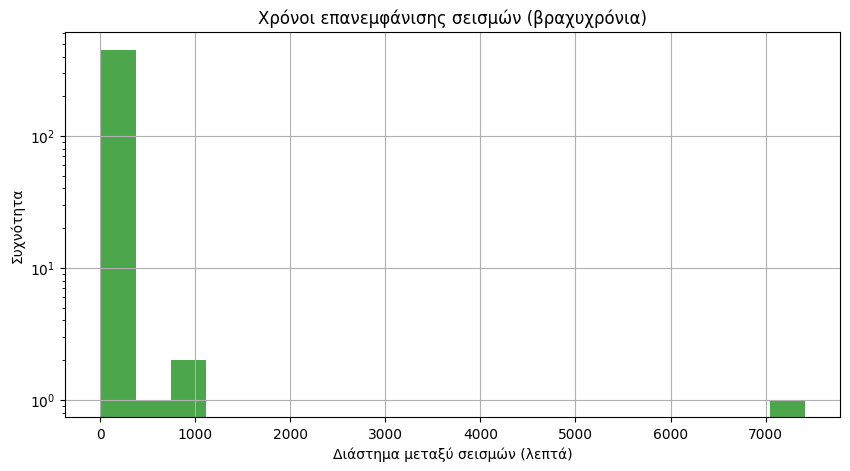


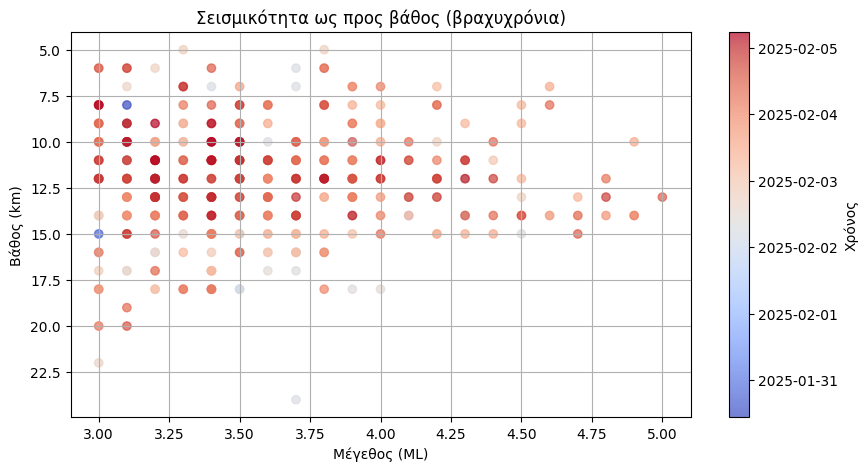

In [ ]:
%%capture_and_save_html

print("\n")
print(f"**Time-series diagrams**")

# --- Χρονική εξέλιξη σεισμών (35 ημέρες) ---
plt.figure(figsize=(10, 5))
plt.scatter(df_35day["Origin Time (GMT)"], df_35day["Magnitude (ML)"], c='b', alpha=0.6)
plt.xlabel("Χρόνος")
plt.ylabel("Μέγεθος (ML)")
plt.title("Χρονική εξέλιξη σεισμών (βραχυχρόνια)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# --- Γράφημα Αθροιστικής Σεισμικότητας ---
df_35day["Cumulative Count"] = range(1, len(df_35day) + 1)
plt.figure(figsize=(10, 5))
plt.plot(df_35day["Origin Time (GMT)"], df_35day["Cumulative Count"], marker='o', linestyle='-', color='r')
plt.xlabel("Χρόνος")
plt.ylabel("Αθροιστικός αριθμός σεισμών")
plt.title("Αθροιστική σεισμικότητα (βραχυχρόνια)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# --- Γράφημα Αθροιστικής Σεισμικής Ενέργειας ---
plt.figure(figsize=(10, 5))
plt.plot(df_35day["Origin Time (GMT)"], df_35day["Cumulative Energy"], marker='o', linestyle='-', color='b')
plt.xlabel("Χρόνος")
plt.ylabel("Αθροιστική Σεισμική Ενέργεια")
plt.title("Αθροιστική Σεισμική Ενέργεια (βραχυχρόνια)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# --- Χρόνοι επανεμφάνισης σεισμών ---
df_35day["Interevent Time"] = df_35day["Origin Time (GMT)"].diff().dt.total_seconds() / 60  # σε λεπτά
df_35day = df_35day.dropna(subset=["Interevent Time"])  # Αφαιρεί την πρώτη NaN τιμή

plt.figure(figsize=(10, 5))
plt.hist(df_35day["Interevent Time"].dropna(), bins=20, color='g', alpha=0.7)
plt.xlabel("Διάστημα μεταξύ σεισμών (λεπτά)")
plt.ylabel("Συχνότητα")
plt.title("Χρόνοι επανεμφάνισης σεισμών (βραχυχρόνια)")
plt.yscale("log")  # Ορισμός λογαριθμικής κλίμακας στον άξονα y
plt.grid()
plt.show()

# --- Σεισμικότητα vs. βάθος ---

# Μετατροπή των timestamps σε datetime
df_35day["Origin Time (GMT)"] = pd.to_datetime(df_35day["Origin Time (GMT)"], unit="s")

plt.figure(figsize=(10, 5))
sc = plt.scatter(df_35day["Magnitude (ML)"], df_35day["Depth (km)"],
                 c=df_35day["Origin Time (GMT)"].map(mdates.date2num),
                 cmap="coolwarm", alpha=0.7)

plt.xlabel("Μέγεθος (ML)")
plt.ylabel("Βάθος (km)")
plt.title("Σεισμικότητα ως προς βάθος (βραχυχρόνια)")

# Μετατροπή της χρωματικής κλίμακας σε μορφή ημερομηνίας
cbar = plt.colorbar(sc, label="Χρόνος")
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Μόνο ημερομηνία

plt.gca().invert_yaxis()  # Αν θέλεις το βάθος να ξεκινά από το 0 στην κορυφή
plt.grid()
plt.show()


In [ ]:
%%capture_and_save_html

print("\n")
print(f"**Series of folium maps**")

def create_heatmap(data, value_col, title):
    """Δημιουργεί heatmap για σεισμικότητα ή ενέργεια."""
    if data.empty:
        raise ValueError("Ο πίνακας δεδομένων είναι άδειος.")

    center_lat = data["Latitude"].mean()
    center_lon = data["Longitude"].mean()

    heat_data = data[["Latitude", "Longitude", value_col]].dropna().values.tolist()

    # Χρήση ESRI Satellite ως υπόβαθρο
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=9,
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri, Maxar, Earthstar Geographics"
    )

    HeatMap(heat_data, radius=10).add_to(m)
    return m



**Series of folium maps**



In [ ]:
#%%capture_and_save_html
print("\n")
print(f"**Σεισμική Συχνότητα (μακροχρόνια)**")

# --- Δημιουργία χαρτών map_10yrs_counts
map_10yrs_counts = create_heatmap(df_10yrs, "Magnitude (ML)", "Σεισμική Συχνότητα (μακροχρόνια)")
map_10yrs_counts



**Σεισμική Συχνότητα (μακροχρόνια)**


In [ ]:
#%%capture_and_save_html
print("\n")
print(f"**Αθροιστική Σεισμική Ενέργεια (μακροχρόνια)**")

# map_10yrs_energy
map_10yrs_energy = create_heatmap(df_10yrs, "Seismic Energy", "Αθροιστική Σεισμική Ενέργεια (μακροχρόνια)")
map_10yrs_energy



**Αθροιστική Σεισμική Ενέργεια (μακροχρόνια)**


In [ ]:
#%%capture_and_save_html
print("\n")
print(f"**Σεισμική Συχνότητα (βραχυχρόνια)**")
# map_35days_counts ---
map_35day_counts = create_heatmap(df_35day, "Magnitude (ML)", "Σεισμική Συχνότητα (βραχυχρόνια)")
map_35day_counts



**Σεισμική Συχνότητα (βραχυχρόνια)**


In [ ]:
#%%capture_and_save_html
print("\n")
print(f"**Αθροιστική Σεισμική Ενέργεια (βραχυχρόνια)**")
# map_35days_energy ---
map_35day_energy = create_heatmap(df_35day, "Seismic Energy", "Αθροιστική Σεισμική Ενέργεια (βραχυχρόνια)")
map_35day_energy



**Αθροιστική Σεισμική Ενέργεια (βραχυχρόνια)**




**Long Term Seismic Density**




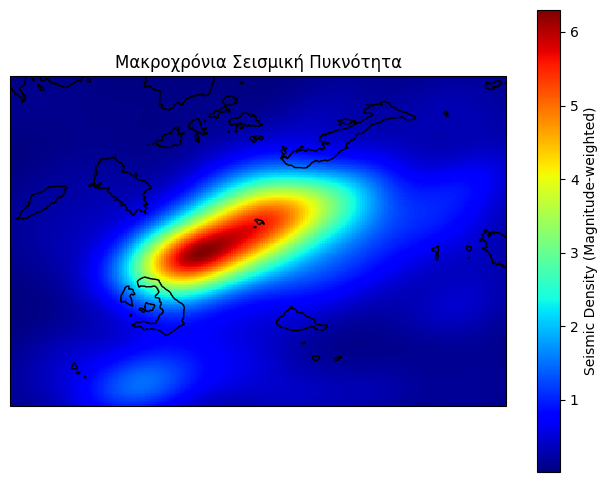

In [ ]:
%%capture_and_save_html
print("\n")
print(f"**Long Term Seismic Density**")

# Φόρτωση δεδομένων σεισμών
lons = df_10yrs["Longitude"].values
lats = df_10yrs["Latitude"].values
magnitudes = df_10yrs["Magnitude (ML)"].values

# Υπολογισμός KDE
xy = np.vstack([lons, lats])
kde = gaussian_kde(xy, weights=magnitudes)

# Δημιουργία κανονικού πλέγματος
grid_lon = np.linspace(lons.min(), lons.max(), 200)
grid_lat = np.linspace(lats.min(), lats.max(), 200)
grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

# Υπολογισμός KDE στο πλέγμα
density = kde(np.vstack([grid_lon.ravel(), grid_lat.ravel()]))
density = density.reshape(grid_lon.shape)

# Δημιουργία του χάρτη
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Σχεδίαση KDE heatmap
mesh = ax.pcolormesh(grid_lon, grid_lat, density, cmap="jet", shading="auto", transform=ccrs.PlateCarree())

# Προσθήκη ακτογραμμής στον χάρτη
ax.add_geometries(coastline.geometry, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1)

# Προσθήκη χρωματικής μπάρας και τίτλων
plt.colorbar(mesh, ax=ax, label="Seismic Density (Magnitude-weighted)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Μακροχρόνια Σεισμική Πυκνότητα")

plt.show()




**Short Term Seismic Density**




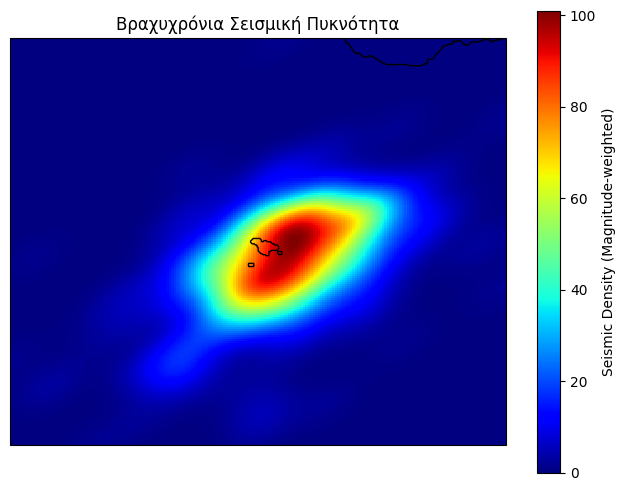

In [ ]:
%%capture_and_save_html
print("\n")
print(f"**Short Term Seismic Density**")

# Φόρτωση δεδομένων σεισμών
lons = df_35day["Longitude"].values
lats = df_35day["Latitude"].values
magnitudes = df_35day["Magnitude (ML)"].values

# Υπολογισμός KDE
xy = np.vstack([lons, lats])
kde = gaussian_kde(xy, weights=magnitudes)

# Δημιουργία κανονικού πλέγματος
grid_lon = np.linspace(lons.min(), lons.max(), 200)
grid_lat = np.linspace(lats.min(), lats.max(), 200)
grid_lon, grid_lat = np.meshgrid(grid_lon, grid_lat)

# Υπολογισμός KDE στο πλέγμα
density = kde(np.vstack([grid_lon.ravel(), grid_lat.ravel()]))
density = density.reshape(grid_lon.shape)

# Δημιουργία του χάρτη
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Σχεδίαση KDE heatmap
mesh = ax.pcolormesh(grid_lon, grid_lat, density, cmap="jet", shading="auto", transform=ccrs.PlateCarree())

# Προσθήκη ακτογραμμής στον χάρτη
ax.add_geometries(coastline.geometry, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1)

# Προσθήκη χρωματικής μπάρας και τίτλων
plt.colorbar(mesh, ax=ax, label="Seismic Density (Magnitude-weighted)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Βραχυχρόνια Σεισμική Πυκνότητα")

plt.show()



**24hrs Weighted Mean Seismic Activity Trajectory with NOA Faults**

<ipython-input-15-21d7165ce6c9>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_35day.groupby("Time Bin", group_keys=False).apply(




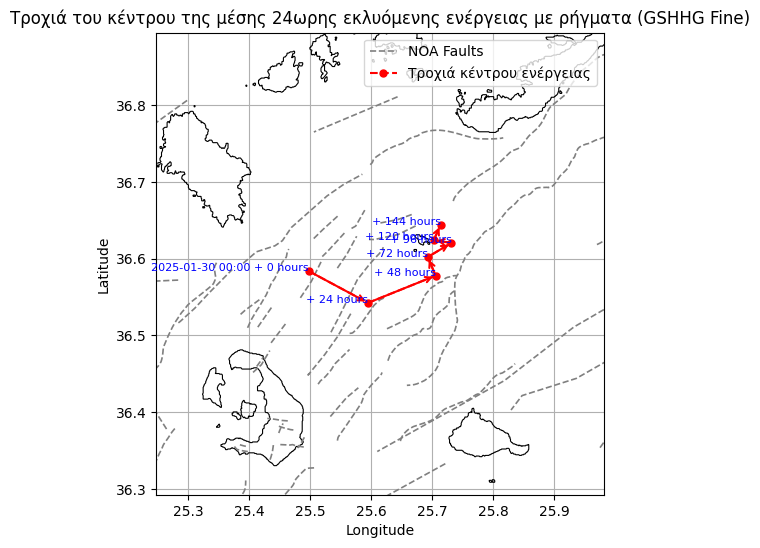

In [ ]:
%%capture_and_save_html

print("\n")
print(f"**24hrs Weighted Mean Seismic Activity Trajectory with NOA Faults**")

# ======= Ορισμός χρονικού παραθύρου =======
time_window = "24h"

# ✅ Ομαδοποίηση σεισμών ανά 24 ώρες και υπολογισμός του κέντρου βάρους της ενέργειας
df_35day["Time Bin"] = df_35day["Origin Time (GMT)"].dt.floor(time_window)

grouped = df_35day.groupby("Time Bin", group_keys=False).apply(
    lambda g: pd.Series({
        "Weighted Lat": np.average(g["Latitude"], weights=g["Seismic Energy"]),
        "Weighted Lon": np.average(g["Longitude"], weights=g["Seismic Energy"]),
        "Date": g["Time Bin"].iloc[0].strftime("%Y-%m-%d %H:%M")  # ✅ Προσθήκη ημερομηνίας ως string
    })
).reset_index()

# ✅ Δημιουργία γεωμετρικών αντικειμένων
grouped["geometry"] = grouped.apply(lambda row: Point(row["Weighted Lon"], row["Weighted Lat"]), axis=1)
trajectory = LineString(grouped["geometry"].values)

# ✅ Ορισμός γεωγραφικών ορίων για την επέκταση της περιοχής
expansion_factor = 0.25  # Αυξήστε για μεγαλύτερη περιοχή
min_lon, max_lon = grouped["Weighted Lon"].min() - expansion_factor, grouped["Weighted Lon"].max() + expansion_factor
min_lat, max_lat = grouped["Weighted Lat"].min() - expansion_factor, grouped["Weighted Lat"].max() + expansion_factor

# ======= Ανάγνωση και σχεδίαση ρηγμάτων =======
faults_file = "/content/NOAFaults_v6.0.gmt.csv"  # Ονομάστε σωστά τη διαδρομή αν αλλάξει
faults = []

# Ανάγνωση του αρχείου γραμμών
with open(faults_file, "r") as file:
    current_fault = []
    for line in file:
        line = line.strip()
        if line == ">" and current_fault:
            faults.append(LineString(current_fault))  # Αποθήκευση προηγούμενου ρήγματος
            current_fault = []  # Επαναφορά λίστας για το νέο ρήγμα
        else:
            parts = line.split()
            if len(parts) == 3:  # Πρέπει να έχει 3 στοιχεία (Lon, Lat, Fault_ID)
                lon, lat = map(float, parts[:2])
                current_fault.append((lon, lat))

    # Προσθήκη του τελευταίου ρήγματος (αν υπάρχει)
    if current_fault:
        faults.append(LineString(current_fault))

# Μετατροπή των ρηγμάτων σε GeoDataFrame
faults_gdf = gpd.GeoDataFrame(geometry=faults, crs="EPSG:4326")

# ======= Σχεδίαση τροχιάς =======
fig, ax = plt.subplots(figsize=(8, 6))

# ✅ Σχεδίαση ολόκληρης της ακτογραμμής χωρίς clipping
coastline = gpd.read_file(coastline_shp)
coastline.boundary.plot(ax=ax, color="black", linewidth=0.8)

# ✅ Σχεδίαση ρηγμάτων
faults_gdf.plot(ax=ax, color="gray", linewidth=1.2, linestyle="--", label="NOA Faults")

# ✅ Ορισμός γεωγραφικών ορίων στον χάρτη
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# ✅ Σχεδίαση τροχιάς με βελάκια
x, y = grouped["Weighted Lon"].values, grouped["Weighted Lat"].values
ax.plot(x, y, linestyle="--", color="red", linewidth=1.5, marker="o", markersize=5, label="Tροχιά κέντρου ενέργειας")
for i in range(len(x) - 1):
    ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

# ✅ Προσθήκη χρονικών ετικετών
t0 = pd.to_datetime(grouped.iloc[0]["Time Bin"])  # Χρόνος πρώτου σημείου
for idx, row in grouped.iterrows():
    t_current = pd.to_datetime(row["Time Bin"])
    delta_hours = (t_current - t0).total_seconds() / 3600  # Διαφορά σε ώρες

    # ✅ Το πρώτο σημείο δείχνει την ημερομηνία + 0 ώρες
    if idx == 0:
        label_text = f"{row['Date']} + 0 hours"
    else:
        label_text = f"+ {int(delta_hours)} hours"

    ax.text(row["Weighted Lon"], row["Weighted Lat"], label_text, fontsize=8, ha='right', color='blue')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Τροχιά του κέντρου της μέσης 24ωρης εκλυόμενης ενέργειας με ρήγματα (GSHHG Fine)")
plt.legend()
plt.grid()
plt.show()


<ipython-input-16-6c1453d21b0d>:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_35day.groupby("Time Bin", group_keys=False).apply(


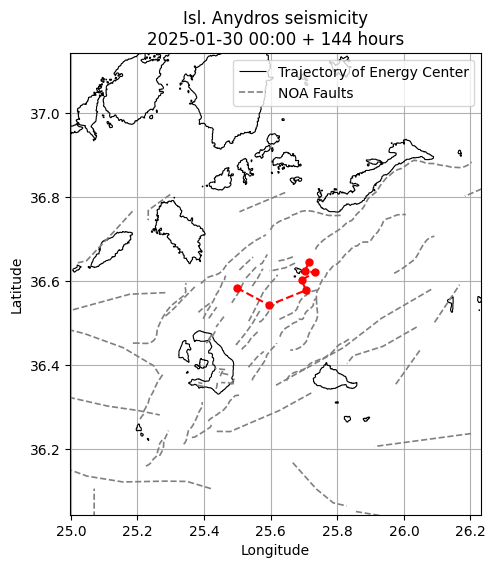

In [ ]:
# ======= Ορισμός χρονικού παραθύρου =======
time_window = "24h"

# ✅ Ομαδοποίηση σεισμών ανά 24 ώρες και υπολογισμός του κέντρου βάρους της ενέργειας
df_35day["Time Bin"] = df_35day["Origin Time (GMT)"].dt.floor(time_window)

grouped = df_35day.groupby("Time Bin", group_keys=False).apply(
    lambda g: pd.Series({
        "Weighted Lat": np.average(g["Latitude"], weights=g["Seismic Energy"]),
        "Weighted Lon": np.average(g["Longitude"], weights=g["Seismic Energy"]),
        "Date": g["Time Bin"].iloc[0].strftime("%Y-%m-%d %H:%M")  # ✅ Προσθήκη ημερομηνίας ως string
    })
).reset_index()

# ✅ Δημιουργία γεωμετρικών αντικειμένων
grouped["geometry"] = grouped.apply(lambda row: Point(row["Weighted Lon"], row["Weighted Lat"]), axis=1)
trajectory = LineString(grouped["geometry"].values)

# ✅ Ορισμός γεωγραφικών ορίων για την επέκταση της περιοχής
expansion_factor = 0.5  # Αυξήστε για μεγαλύτερη περιοχή
min_lon, max_lon = grouped["Weighted Lon"].min() - expansion_factor, grouped["Weighted Lon"].max() + expansion_factor
min_lat, max_lat = grouped["Weighted Lat"].min() - expansion_factor, grouped["Weighted Lat"].max() + expansion_factor

# ✅ Χρήση των ορίων χωρίς clipping της ακτογραμμής
bounding_box = gpd.GeoDataFrame(geometry=[box(min_lon, min_lat, max_lon, max_lat)], crs="EPSG:4326")

# ======= Ανάγνωση και σχεδίαση ρηγμάτων =======
faults_file = "/content/NOAFaults_v6.0.gmt.csv"  # Βεβαιωθείτε ότι υπάρχει το αρχείο στη σωστή διαδρομή
faults = []

# Ανάγνωση του αρχείου γραμμών
with open(faults_file, "r") as file:
    current_fault = []
    for line in file:
        line = line.strip()
        if line == ">" and current_fault:
            faults.append(LineString(current_fault))  # Αποθήκευση προηγούμενου ρήγματος
            current_fault = []  # Επαναφορά λίστας για το νέο ρήγμα
        else:
            parts = line.split()
            if len(parts) == 3:  # Πρέπει να έχει 3 στοιχεία (Lon, Lat, Fault_ID)
                lon, lat = map(float, parts[:2])
                current_fault.append((lon, lat))

    # Προσθήκη του τελευταίου ρήγματος (αν υπάρχει)
    if current_fault:
        faults.append(LineString(current_fault))

# Μετατροπή των ρηγμάτων σε GeoDataFrame
faults_gdf = gpd.GeoDataFrame(geometry=faults, crs="EPSG:4326")

# ✅ Δημιουργία Animation
fig, ax = plt.subplots(figsize=(8, 6))

# ✅ Σχεδίαση ολόκληρης της ακτογραμμής
coastline = gpd.read_file(coastline_shp)
coastline.boundary.plot(ax=ax, color="black", linewidth=0.8)

# ✅ Σχεδίαση των ρηγμάτων
faults_gdf.plot(ax=ax, color="gray", linewidth=1.2, linestyle="--", label="NOA Faults")

# ✅ Ορισμός γεωγραφικών ορίων στον χάρτη
ax.set_xlim(min_lon, max_lon)
ax.set_ylim(min_lat, max_lat)

# ✅ Σχεδίαση κενής τροχιάς
line, = ax.plot([], [], linestyle="--", color="red", linewidth=1.5, marker="o", markersize=5)

# ✅ Προετοιμασία τίτλου animation
title_text = ax.set_title("Isl. Anydros seismicity")

# ✅ Χρονικό σημείο αναφοράς (πρώτος σεισμός)
t0 = pd.to_datetime(grouped.iloc[0]["Time Bin"])

# ✅ Συναρτήσεις animation
def init():
    """ Αρχικοποιεί το animation (κενός χάρτης). """
    line.set_data([], [])
    title_text.set_text("Isl. Anydros seismicity")
    return line, title_text

def update(frame):
    """ Προσθέτει σημεία στην τροχιά σταδιακά. """
    x = grouped["Weighted Lon"].values[:frame + 1]
    y = grouped["Weighted Lat"].values[:frame + 1]

    # ✅ Ενημέρωση της τροχιάς στο animation
    line.set_data(x, y)

    # ✅ Υπολογισμός της χρονικής διαφοράς από το πρώτο σημείο
    t_current = pd.to_datetime(grouped.iloc[frame]["Time Bin"])
    delta_hours = (t_current - t0).total_seconds() / 3600  # Διαφορά σε ώρες

    # ✅ Δημιουργία τίτλου (πρώτο σημείο: ημερομηνία, μετά: + ώρες)
    if frame == 0:
        title_text.set_text(f"Isl. Anydros seismicity\n{grouped.iloc[0]['Date']} + 0 hours")
    else:
        title_text.set_text(f"Isl. Anydros seismicity\n{grouped.iloc[0]['Date']} + {int(delta_hours)} hours")

    return line, title_text

# ✅ Δημιουργία του animation
ani = animation.FuncAnimation(fig, update, frames=len(grouped), init_func=init, interval=1000, blit=True)

# ✅ Αποθήκευση ή προβολή
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(["Trajectory of Energy Center", "NOA Faults"])
plt.grid()

# Προβολή του animation στο notebook
from IPython.display import HTML
HTML(ani.to_jshtml())


In [ ]:
%%capture_and_save_html
print("\n")
print(f"**Animation ready for download @ colab files**")

ani.save("trajectory_animation.mp4", writer="ffmpeg", fps=1)
ani.save("trajectory_animation.gif", fps=1, writer="pillow")




**Animation ready for download @ colab files**



In [ ]:
from google.colab import files #Reimporting the module
files.download(html_file_path) #Calling the download function
files.download("trajectory_animation.gif")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>